In [1]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc

# Enable vector-friendly mode (rasterizes large scatter plots automatically) 

sc.settings.vector_friendly = True 

# Increase DPI for high-resolution rendering 

sc.set_figure_params(dpi=300)

import matplotlib as mpl
from matplotlib.colors import Normalize
# Make PDF text editable in Illustrator
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"

# Optional but helpful: use a common font
mpl.rcParams["font.family"] = "DejaVu Sans"
mpl.rcParams["font.size"] = 7
mpl.rcParams["axes.titlesize"] = 7
mpl.rcParams["axes.labelsize"] = 7
mpl.rcParams["xtick.labelsize"] = 6
mpl.rcParams["ytick.labelsize"] = 6
mpl.rcParams["legend.fontsize"] = 6

In [2]:
data_dir = Path("/path/to/data/scrna_seq/simulation_shift_realistic")
fig_dir = data_dir / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

nhood_size = 20

simulation_type = "shift"  # "de" or "shift"

# Read the scCST result written by sccst_simulation_shift.ipynb (has rra_cell_divergence_score).
sim_adata = sc.read_h5ad(data_dir / "sccst_results" / f"sccst_result_{simulation_type}_nhood_{nhood_size}.h5ad")

sim_adata = sim_adata[sim_adata.obs['condition'] == 'Disease'].copy()

sim_df = sim_adata.obs[['rra_cell_divergence_score']]

In [3]:
sim_df.head()

,rra_cell_divergence_score
1393_disease,33.868168
2349_disease,34.975273
299_disease,34.448601
436_disease,35.869854
128_disease,33.628532


In [4]:
#for each cell in srda_ds, get the number of genes in cluster_genes_dict and calculate correlation between phenotypic_score and number of genes in cluster_genes_dict
num_genes_in_cluster = []
divergence_scores = []
for cell in sim_df.index:
    cell_type = sim_adata.obs.loc[cell, "Cell_Type"]
    num_genes = len(sim_adata.uns['cell_type_markers'][cell_type])
    num_genes_in_cluster.append(num_genes)
    divergence = sim_df.loc[cell, 'rra_cell_divergence_score']
    divergence_scores.append(divergence)

spearman_corr, p_val = spearmanr(divergence_scores, num_genes_in_cluster)

print(f"Spearman correlation between divergence score and number of genes in cluster: {spearman_corr}")

Spearman correlation between divergence score and number of genes in cluster: 0.9949875234770684


In [5]:
df_plot = pd.DataFrame({
    'divergence_score': divergence_scores,
    'num_genes_in_cluster': num_genes_in_cluster
})

In [6]:
df_plot 

,divergence_score,num_genes_in_cluster
0,33.868168,5
1,34.975273,5
2,34.448601,5
3,35.869854,5
4,33.628532,5
...,...,...
2395,192.685516,50
2396,193.245056,50
2397,193.123001,50
2398,195.165680,50


In [7]:
df_plot.divergence_score = (df_plot.divergence_score - df_plot.divergence_score.min()) / (df_plot.divergence_score.max() - df_plot.divergence_score.min())

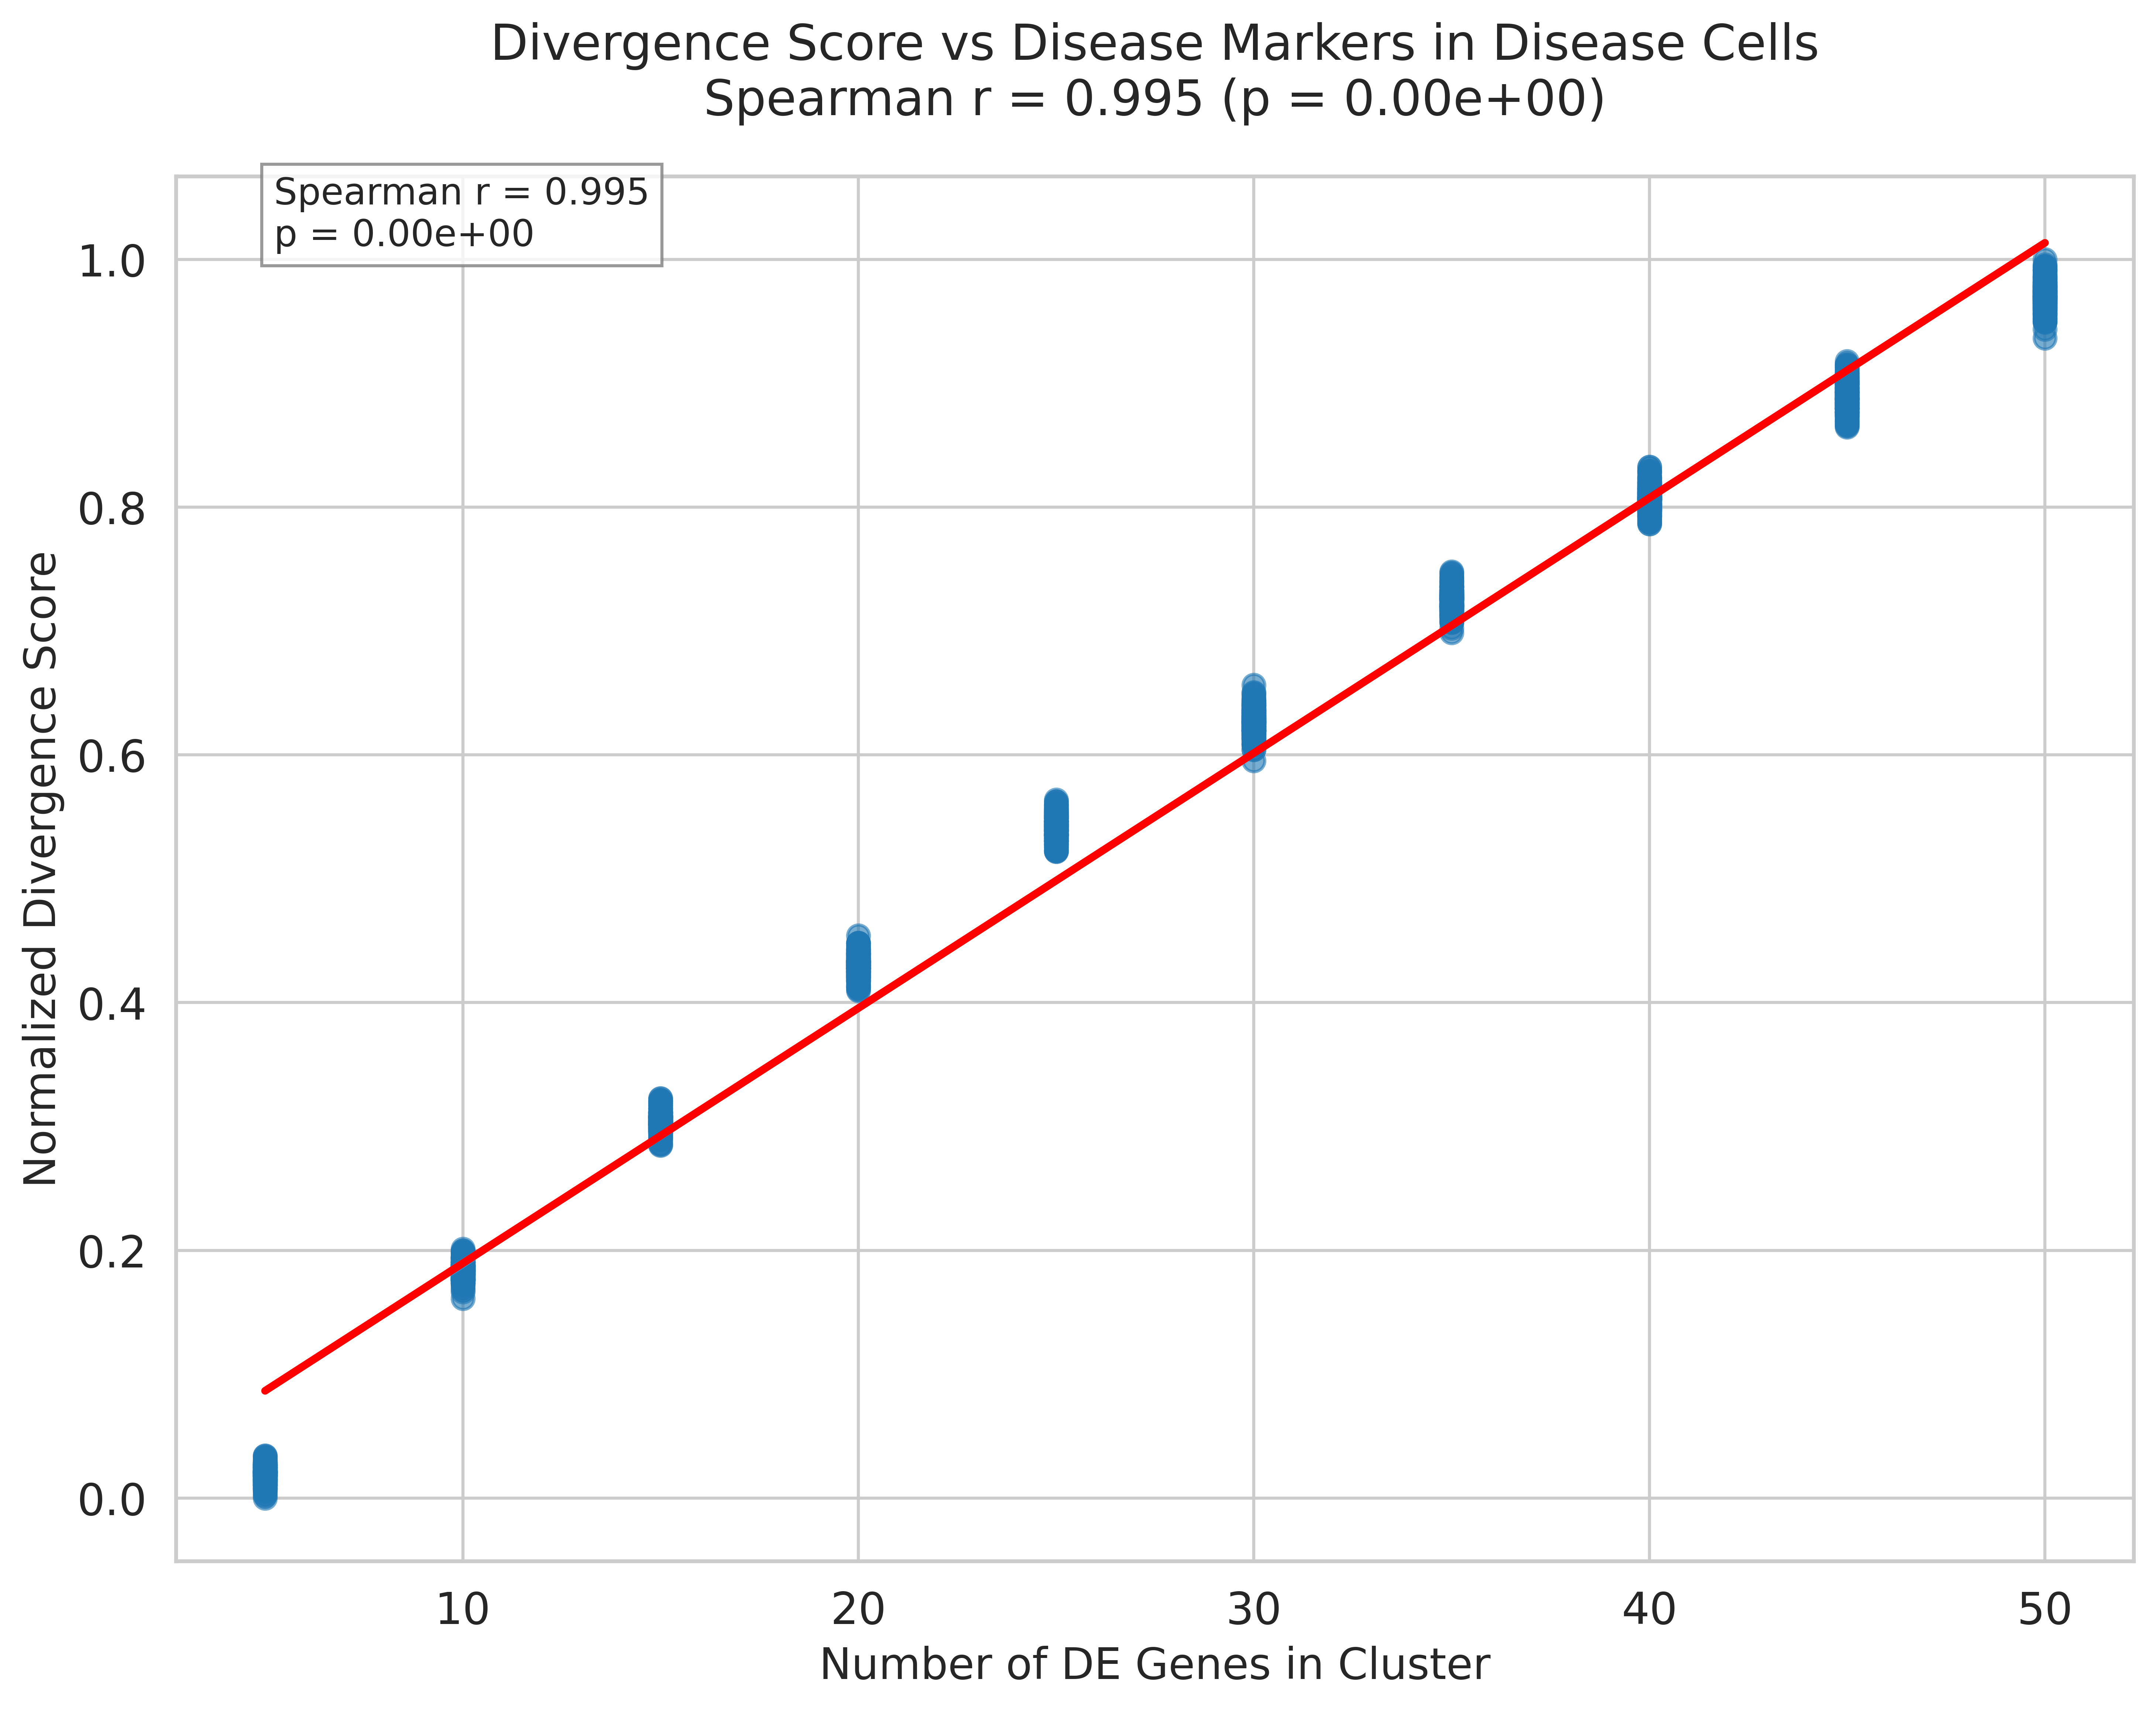

In [8]:
# Single scatter plot with regression line
plt.figure(figsize=(10, 8))
sns.set(style="whitegrid", font_scale=1.3)

sns.regplot(
    data=df_plot,
    x='num_genes_in_cluster',
    y='divergence_score',
    scatter_kws={'alpha': 0.6, 'color': '#1f77b4', 's': 50},
    line_kws={'color': 'red', 'lw': 2.5},
    logistic=False  # Change to True if scores are binary-like
)

plt.title(f'Divergence Score vs Disease Markers in Disease Cells\nSpearman r = {spearman_corr:.3f} (p = {p_val:.2e})', 
          fontsize=16, pad=20)
plt.xlabel('Number of DE Genes in Cluster', fontsize=14)
plt.ylabel('Normalized Divergence Score', fontsize=14)

plt.yscale('linear')

# Optional: Add correlation text on plot
plt.text(0.05, 0.95, f'Spearman r = {spearman_corr:.3f}\np = {p_val:.2e}',
         transform=plt.gca().transAxes, fontsize=12,
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()
plt.savefig(fig_dir / f'sccst_shift_divergence_scores_vs_num_genes_nhood{nhood_size}_{simulation_type}.pdf', dpi=300)
plt.show()
plt.close()

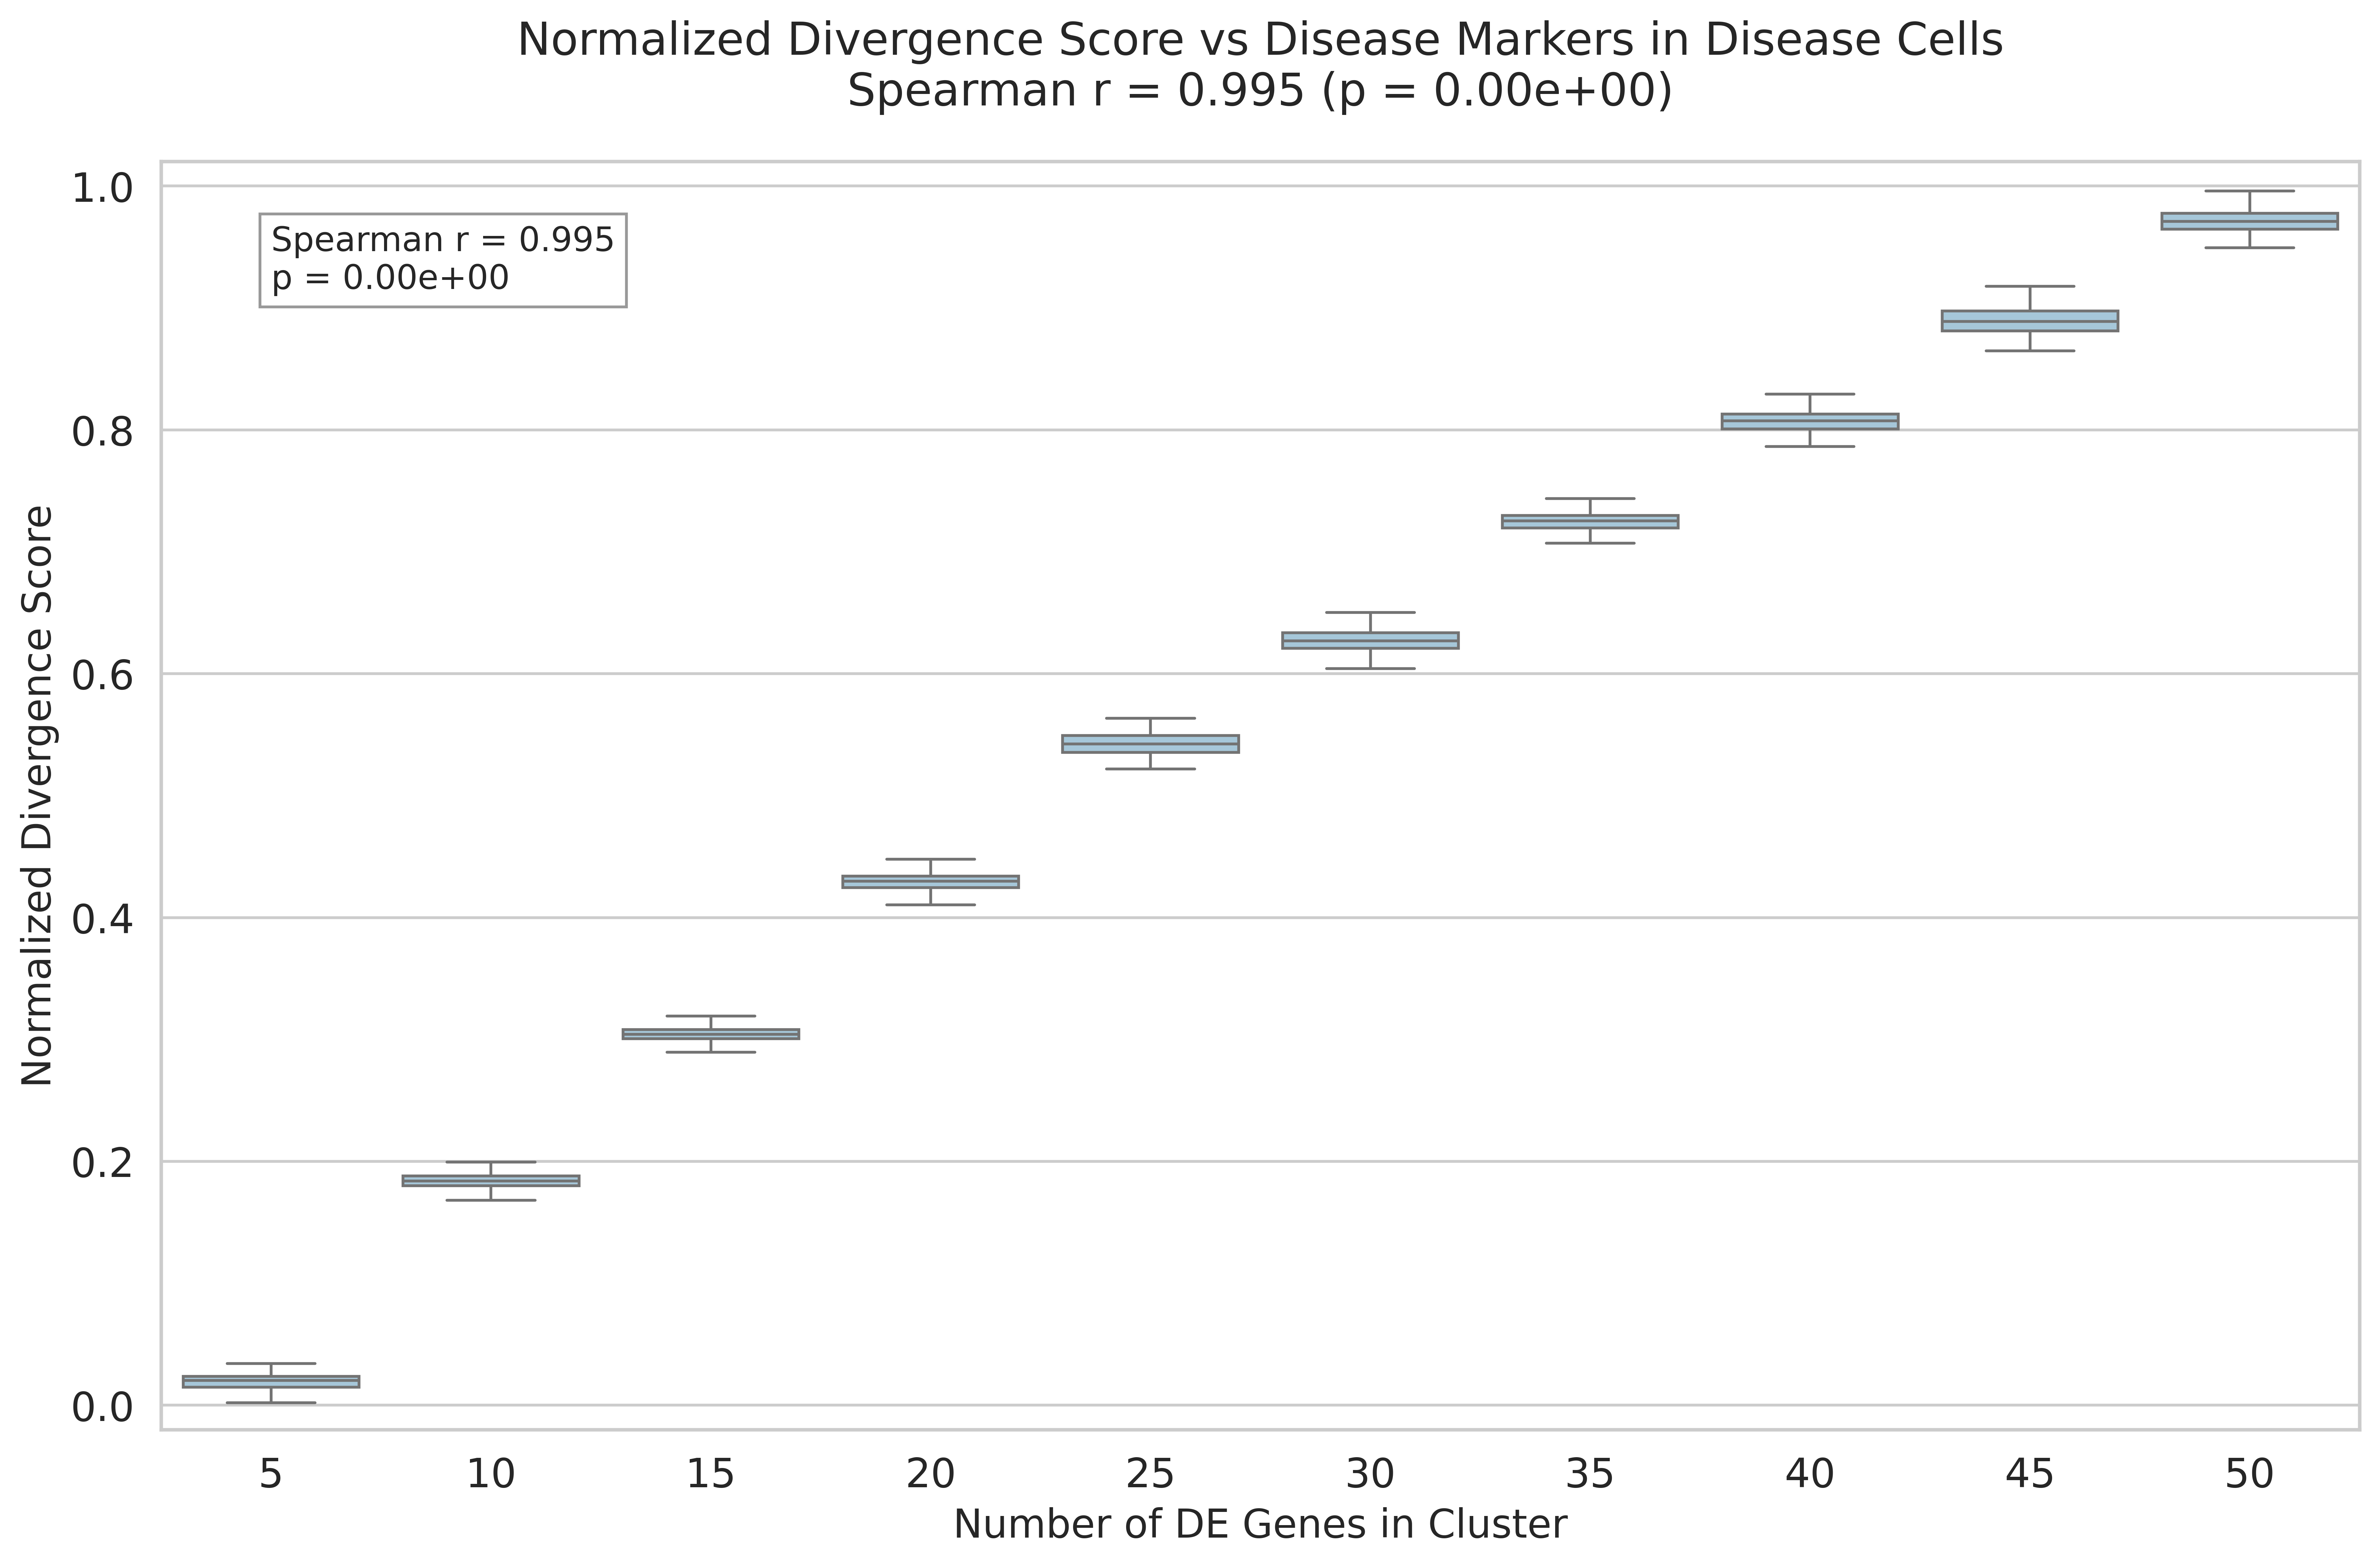

In [9]:
# Boxplot of normalized divergence score by number of genes in cluster
plt.figure(figsize=(12, 8))
sns.set(style="whitegrid", font_scale=1.3)

sns.boxplot(
    data=df_plot,
    x='num_genes_in_cluster',
    y='divergence_score',
    color='#9ecae1',
    showfliers=False
)

plt.title(
    f'Normalized Divergence Score vs Disease Markers in Disease Cells\n'
    f'Spearman r = {spearman_corr:.3f} (p = {p_val:.2e})',
    fontsize=16,
    pad=20
)

plt.xlabel('Number of DE Genes in Cluster', fontsize=14)
plt.ylabel('Normalized Divergence Score', fontsize=14)

plt.yscale('linear')
plt.ylim(-0.02, 1.02)

plt.text(
    0.05,
    0.95,
    f'Spearman r = {spearman_corr:.3f}\np = {p_val:.2e}',
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray')
)

plt.tight_layout()
plt.savefig(
    fig_dir / f'scsct_shift_divergence_scores_boxplot_vs_num_genes_nhood{nhood_size}_{simulation_type}.pdf',
    dpi=300
)
plt.show()
plt.close()